In [27]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mistralai import Mistral
from dotenv import load_dotenv
from io import BytesIO

load_dotenv()
api_key = os.getenv("MISTRAL_API_KEY")

In [2]:
from mistralai import Mistral

# Specify model
model = "pixtral-12b-2409"

# Initialize the Mistral client
client = Mistral(api_key=api_key)

# Define the messages for the chat
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": "Describe the image."
            },
            {
                "type": "image_url",
                "image_url": "https://eloking.com/storage/blog-images/xsXH1mW7ZPLsigfyeIdGPjT4NEHFhM6WmQLqVRrY.png"
            }
        ]
    }
]

# Get the chat response
chat_response = client.chat.complete(
    model=model,
    messages=messages
)

# Print the content of the response
print(chat_response.choices[0].message.content)

The image captures a moment of intense action in a video game. The player's hand, clad in a black glove, grips a gun that is a riot of colors. The gun, adorned with a floral pattern in hues of pink, green, and yellow, stands out against the backdrop of the game. The barrel of the gun is pointed towards the right side of the image, suggesting the direction of the player's aim.

The background is a dramatic tableau of a sunset, with the sky painted in shades of orange and pink. A lightning bolt cuts across the sky, adding a sense of urgency to the scene. The text "from eloking.com" is visible, possibly indicating the source or creator of the game.

The image is a snapshot of a thrilling moment, where the player's skill and strategy are put to the test against the backdrop of a vibrant and dynamic game world.


In [3]:
import base64

def encode_image_base64(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

In [14]:
def preProcessImage(image):
    # Convert the image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply Adaptive Thresholding
    thresh = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
    )

    # Define a kernel for morphological operations
    kernel = np.ones((1, 1), np.uint8)
    
    # Apply Morphological Opening (remove noise)
    text_processed = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)

    # Extract horizontal lines
    horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1))
    horizontal_lines = cv2.morphologyEx(text_processed, cv2.MORPH_OPEN, horizontal_kernel)
    
    # Extract vertical lines
    vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 40))
    vertical_lines = cv2.morphologyEx(text_processed, cv2.MORPH_OPEN, vertical_kernel)
    
    # Combine the detected lines
    table_processed = cv2.addWeighted(horizontal_lines, 0.5, vertical_lines, 0.5, 0)

    # Use bitwise OR to combine text and table images
    final_processed = cv2.bitwise_or(text_processed, table_processed)

    return final_processed

In [32]:
def loadImage(path):
    #image = encode_image_base64("images/IMG_0217.jpg")
    image_path = path  
    image = cv2.imread(image_path)
    img_name = path
    page_type = "Simple"
    
    # Correct the scan orientation
    
    ## Convert the image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    ## Apply Gaussian blur to reduce noise
    blurImg = cv2.GaussianBlur(gray, (101, 51), 61)
    
    ## Apply adaptive thresholding to create a binary image
    thresh = cv2.adaptiveThreshold(blurImg, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 71, 2)
    
    ## Dilate the image to connect text components
    kernel = np.ones((1, 25), np.uint8)
    img_dilation = cv2.dilate(thresh, kernel, iterations=1)
    
    ## Invert image colors
    invert = cv2.bitwise_not(img_dilation)
    
    ## Find contours of text components
    ctrs, hier = cv2.findContours(invert.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    ## Find the primary contour with the largest area
    primary_contour = max(ctrs, key=cv2.contourArea)
    
    ## Fit a rotated bounding box to the primary contour
    rect = cv2.minAreaRect(primary_contour)
    box = cv2.boxPoints(rect)
    box = np.intp(box)
    
    ## Get the angle of the skew from the rotated bounding box
    angle = -rect[-1]
    print ('angle is: ', angle)
    
    ## Limit the angle to avoid wrong vertical rotation
    max_allowed_angle = 1.5
    if abs(angle) > max_allowed_angle:
        angle = np.sign(angle) * max_allowed_angle
    
    ## Rotate the image to correct the skew
    rows, cols = image.shape[:2]
    M = cv2.getRotationMatrix2D((cols // 2, rows // 2), angle, 1)
    corrected_image = cv2.warpAffine(image, M, (cols, rows), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_WRAP)

    processed_image = preProcessImage(corrected_image)
    
    # Display the grayscale image
    plt.figure(figsize=(10, 8))
    plt.imshow(processed_image, cmap="gray")
    plt.axis("off")
    plt.title("Processed Image")
    plt.show()
    
    # Convert the corrected image to JPEG format
    _, buffer = cv2.imencode('.jpg', processed_image)
    
    # Encode the JPEG image to base64
    return base64.b64encode(buffer).decode('utf-8')

angle is:  -88.7939453125


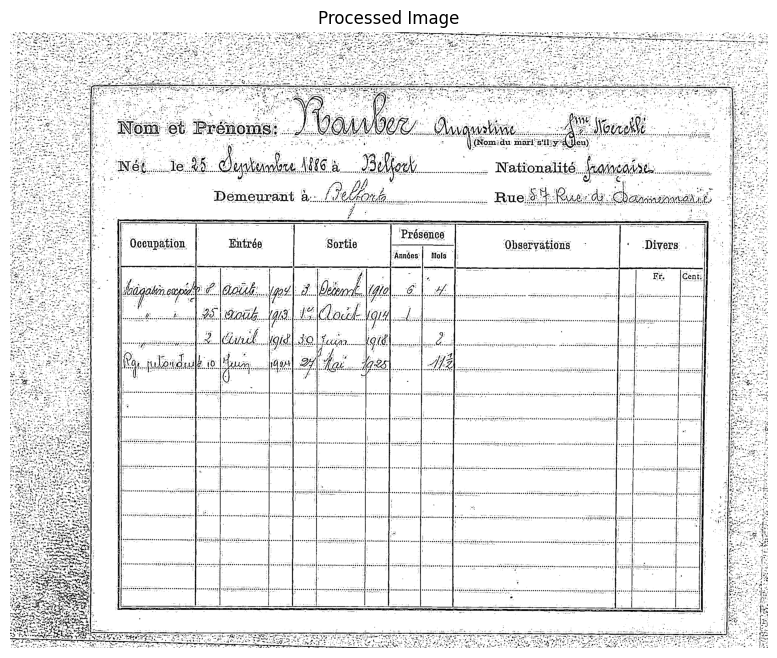

Based on the provided images, here is the extracted information from the document's header:

- **Name (Last and First name):** Rauber Augustine
- **Last name of Husband ('Fme' mean 'wife of'):** J. Moucheli
- **Status:** (Not specified in the provided text)
- **Date of Birth:** (Not specified in the provided text)
- **Place of Birth:** Belfort
- **Nationality:** Française
- **City:** Belfort
- **Street:** Rue St. Pierre de Dannemarie

The document appears to be a record from Belfort, France, and it includes details about an individual named Rauber Augustine, who is identified as the wife of J. Moucheli. The street mentioned is "Rue St. Pierre de Dannemarie."


In [55]:
img_name = "images/IMG_0217.jpg"
image = loadImage(img_name)
comp_img = encode_image_base64(img_name)

# Define the messages for the chat
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": """You are a specilized automated scanner for french manuscript documents from the city Belfort. Theses documents are very hard to read and contains information about an individual.
You'll need to extract the following informations from the document's header: Name (Last and First name), Last name of Husband ('Fme' mean 'wife of'), Status (divorced, ...), Date of Birth, Place of Birth, Nationality, City, Street (must have the name of the street and a number). The first line of the header contains the name of the individual, the husband name and their status (divorced, ...). Take into account that there might be abreviation. Do not introduce errors, hallucinate content, or modify extracted text. Don't imply anything and write only what is visible on the file. Use both images to compare the results and use the most probable output."""
            },
            {
                "type": "text",
                "text": "The name of the file is" + img_name
            },
            {
                "type": "image_url",
                "image_url": f"data:image/jpeg;base64,{comp_img}"
            },
            {
                "type": "image_url",
                "image_url": f"data:image/jpeg;base64,{image}"
            },
        ],
        
    }
]

# Get the chat response
chat_response = client.chat.complete(
    model=model,
    messages=messages
)

# Print the content of the response
print(chat_response.choices[0].message.content)

In [5]:
# Prompt potentielle :
"""You are an OCR assistant that extracts text from segmented images and outputs XML in the **Belfort Archives format**, 
ensuring compatibility with a text processing pipeline that utilizes the `ReadTxtFile` class. 

Perform OCR on the provided image, preserving text order exactly as it appears. Follow this XML structure:

<Page Name="[IMAGE_NAME]" Type="Double page" ImageHeight="[HEIGHT]" ImageWidth="[WIDTH]">
    <ReadingOrder>
        <RegionRefIndexed Index="1" Type="Number"/>
        <RegionRefIndexed Index="2" Type="Name"/>
        <RegionRefIndexed Index="3" Type="Name"/>
        <RegionRefIndexed Index="4" Type="Paragraph"/>
    </ReadingOrder>
    <TextRegion Index="1" Type="Number">
        <Coords Points="(x1, y1, x2, y2)"/>
        <TextEquiv>
            <Unicode>[Extracted Number]</Unicode>
        </TextEquiv>
    </TextRegion>
    <TextRegion Index="2" Type="Name">
        <Coords Points="(x1, y1, x2, y2)"/>
        <TextEquiv>
            <Unicode>[Extracted Name]</Unicode>
        </TextEquiv>
    </TextRegion>
    <TextRegion Index="4" Type="Paragraph">
        <Coords Points="(x1, y1, x2, y2)"/>
        <TextEquiv>
            <Unicode>
                <text>[Extracted paragraph text]</text>
            </Unicode>
        </TextEquiv>
        <TextLine ID="1">
            <Coords Points="(x1, y1, x2, y2)"/>
            <TextEquiv>
                <Unicode>
                    <text>[Extracted line text]</text>
                </Unicode>
            </TextEquiv>
        </TextLine>
    </TextRegion>
</Page>

Wrap extracted text inside `<text>` tags, ensure correct placement of `<page>`, `<text>`, and `</text>` tags for `ReadTxtFile` compatibility. 
Maintain `ReadingOrder` elements, use `<Coords>` for each `<TextRegion>` and `<TextLine>`, and replace `[IMAGE_NAME]` with the provided filename 
(e.g., `1E31_0027.jpg`). Do not introduce errors, hallucinate content, or modify extracted text. 

Ensure **perfect adherence to this structure**, maintaining text integrity while ensuring compatibility with post-processing scripts.
"""



"Can you please carefully analyze the asset and transcribe it: it is very hard to read and you must run multiple OCR carefully to get the perfect result we are looking for. To increase accuracy of your results you must try these techniques to improve text recognition one-after-another and step-by-step. Tasks =Apply these custom configurations in OCR to improve text recognition: Image Enhancement: Improve the image contrast and apply sharpening to make the text clearer. Grayscale Conversion: Convert the image to grayscale to simplify the text extraction process. Black and White Conversion: Transform the image to black and white to enhance text visibility. Adaptive Thresholding: Use adaptive thresholding to handle varying lighting conditions within the image. Segmentation: Split the image into smaller, more manageable sections and apply OCR individually to each section. Custom OCR Configurations: Try and apply different custom configurations in OCR to improve text recognition."


"""You are a French historian specialized in the manuscript documents. Can you please carefully analyze the asset and transcribe it (XML format): it is very hard to read and you must run multiple OCR carefully to get the perfect result we are looking for. To increase accuracy of your results you must try these techniques to improve text recognition one-after-another and step-by-step. Tasks =Apply these custom configurations in OCR to improve text recognition: Image Enhancement: Improve the image contrast and apply sharpening to make the text clearer. Grayscale Conversion: Convert the image to grayscale to simplify the text extraction process. Black and White Conversion: Transform the image to black and white to enhance text visibility. Adaptive Thresholding: Use adaptive thresholding to handle varying lighting conditions within the image. Segmentation: Split the image into smaller, more manageable sections and apply OCR individually to each section. Custom OCR Configurations: Try and apply different custom configurations in OCR to improve text recognition. If a cell is empty write [empty]. `"` represent a repetition of the word above (for example, if the word above is test, then replace `"` by test. The first item of a row can't be a date."""


"""You are a specilized automated scanner for manuscript documents. Theses documents are very hard to read and contains information about an individual.
You'll need to extract the following informations from the document's header: Name, Date of Birth, Place of Birth, Nationality, City, Street. Then you should analyse the table row by row which has this layout:
<Table>
    <Header>
        <Column>Workshop</Column>
        <Column>Occupation</Column>
        <Column>Entry Date</Column>
        <Column>Exit Date</Column>
        <Column>Presence (Years)</Column>
        <Column>Presence (Months)</Column>
        <Column>Observations</Column>
        <Column>Miscellaneous (Fr.)</Column>
        <Column>Miscellaneous (Cent.)</Column>
    </Header>
    <Row>...</Row>
    <Row>...</Row>
</Table>
Some of the columns items in a row are missing: you should write [empty] in the corresponding cell.
If there is a quote in the text, you should replace it by the word above.
The output should be in XML format.
Inside the <Row> tag, the order of the columns should be the same as in the header and should be named as the header.
Do OCR for both images given and compare the result to correct them.
"""

'Can you please carefully analyze the asset and transcribe it: it is very hard to read and you must run multiple OCR carefully to get the perfect result we are looking for. To increase accuracy of your results you must try these techniques to improve text recognition one-after-another and step-by-step. Tasks =Apply these custom configurations in OCR to improve text recognition: Image Enhancement: Improve the image contrast and apply sharpening to make the text clearer. Grayscale Conversion: Convert the image to grayscale to simplify the text extraction process. Black and White Conversion: Transform the image to black and white to enhance text visibility. Adaptive Thresholding: Use adaptive thresholding to handle varying lighting conditions within the image. Segmentation: Split the image into smaller, more manageable sections and apply OCR individually to each section. Custom OCR Configurations: Try and apply different custom configurations in OCR to improve text recognition.'